In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/online_retail_clean.csv', parse_dates=['InvoiceDate'])
print(df.shape)

(779495, 9)


In [6]:
# Reference date = day after last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)

rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).round(2)

print(rfm.shape)
rfm.describe()


Reference date: 2011-12-10 12:50:00
(5881, 3)


,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000
mean,201.457745,6.287196,2954.396234
std,209.474135,13.012879,14437.322633
min,1.000000,1.000000,0.000000
25%,26.000000,1.000000,341.900000
50%,96.000000,3.000000,865.600000
75%,380.000000,7.000000,2247.720000
max,739.000000,398.000000,580987.040000


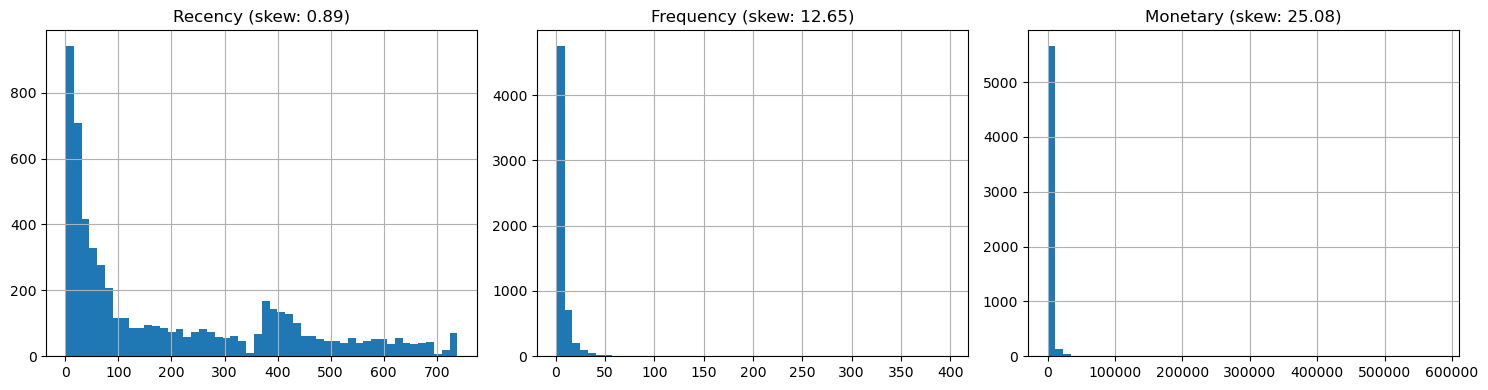

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rfm['Recency'].hist(bins=50, ax=axes[0])
axes[0].set_title(f'Recency (skew: {rfm["Recency"].skew():.2f})')

rfm['Frequency'].hist(bins=50, ax=axes[1])
axes[1].set_title(f'Frequency (skew: {rfm["Frequency"].skew():.2f})')

rfm['Monetary'].hist(bins=50, ax=axes[2])
axes[2].set_title(f'Monetary (skew: {rfm["Monetary"].skew():.2f})')

plt.tight_layout()
plt.show()


In [8]:
rfm.to_csv('../data/processed/rfm.csv')
print("Saved.")


Saved.


Recency skewness (0.89) is mild and close to normal. Frequency (12.65) and Monetary (25.08) are extremely right-skewed. All three will still be log-transformed for consistency, but the critical motivation applies mainly to F and M."